In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd "/content/drive/MyDrive/Road_to_Data_Sci/Deep_Learning/Pytorch_Learning/NLP_Disaster_Tweets"

/content/drive/MyDrive/Road_to_Data_Sci/Deep_Learning/Pytorch_Learning/NLP_Disaster_Tweets


# **Data Understanding & Data Collection**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df =pd.read_csv("train.csv")
df.tail()

,id,keyword,location,text,target
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1
7612,10873,NaN,NaN,The Latest: More Homes Razed by Northern Calif...,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [ ]:
df.dtypes

,0
id,int64
keyword,object
location,object
text,object
target,int64


In [ ]:
df.describe()

,id,target
count,7613.000000,7613.00000
mean,5441.934848,0.42966
std,3137.116090,0.49506
min,1.000000,0.00000
25%,2734.000000,0.00000
50%,5408.000000,0.00000
75%,8146.000000,1.00000
max,10873.000000,1.00000


In [ ]:
df.isnull().sum()

,0
id,0
keyword,61
location,2533
text,0
target,0


In [ ]:
df.nunique()

,0
id,7613
keyword,221
location,3341
text,7503
target,2


# **Data Wrangling (Data Preparation/Cleaning)**

In [ ]:
df['keyword'] = df['keyword'].fillna("unknown")
df['location'] = df['location'].fillna("unknown")

In [ ]:
df = df.drop('id', axis=1)

In [ ]:
df.isnull().sum()

,0
keyword,0
location,0
text,0
target,0


In [ ]:
df.head()

,keyword,location,text,target
0,unknown,unknown,Our Deeds are the Reason of this #earthquake M...,1
1,unknown,unknown,Forest fire near La Ronge Sask. Canada,1
2,unknown,unknown,All residents asked to 'shelter in place' are ...,1
3,unknown,unknown,"13,000 people receive #wildfires evacuation or...",1
4,unknown,unknown,Just got sent this photo from Ruby #Alaska as ...,1


In [ ]:
import re
def clean_text (text):
  text =text.lower()
  text =re.sub(r"http\S+", '', text)
  text =re.sub(r'<.*?', '', text)
  text =re.sub(r'@\w+', '', text)
  text =re.sub(r'#', '', text)
  text =re.sub(r'[^a-zA-Z\s]', '', text)
  text =re.sub(r'\s+', ' ', text).strip()

  return text

In [ ]:
raw_tweet = "🔥BREAKING: #Floods in California! See photos at http://tiny.cc/pics @CNN reports. &amp; Stay safe!"
cleaned_tweet = clean_text(raw_tweet)

print(f"🔴 ก่อน: {raw_tweet}")
print(f"🟢 หลัง: {cleaned_tweet}")

🔴 ก่อน: 🔥BREAKING: #Floods in California! See photos at http://tiny.cc/pics @CNN reports. &amp; Stay safe!
🟢 หลัง: breaking floods in california see photos at reports amp stay safe


In [ ]:
df['clean_text'] =df['text'].apply(clean_text)
df[['text', 'clean_text']].head(10)

,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders in ...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy closed in both...
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain causes flash floodin...
7,I'm on top of the hill and I can see a fire in...,im on top of the hill and i can see a fire in ...
8,There's an emergency evacuation happening now ...,theres an emergency evacuation happening now i...
9,I'm afraid that the tornado is coming to our a...,im afraid that the tornado is coming to our area


# **Model Building & Evaluation**

In [ ]:
from sklearn.model_selection import train_test_split

X = df['clean_text'].values
y = df['target'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"📚 ข้อมูลเทรน: {len(X_train)} แถว")
print(f"📝 ข้อมูลสอบ:  {len(X_val)} แถว")

📚 ข้อมูลเทรน: 6090 แถว
📝 ข้อมูลสอบ:  1523 แถว


In [ ]:
from datasets import Dataset, DatasetDict
import pandas as pd

df_train = pd.DataFrame({'text': X_train, 'label': y_train})
df_val = pd.DataFrame({'text': X_val, 'label': y_val})

dataset = DatasetDict({
    'train': Dataset.from_pandas(df_train),
    'validation': Dataset.from_pandas(df_val)
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 6090
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1523
    })
})


In [ ]:
from transformers import AutoTokenizer, AutoModel, DataCollatorWithPadding
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
from tqdm import tqdm
import torch.nn.functional as F

model_checkpoint ='roberta-base'
tokenizer =AutoTokenizer.from_pretrained(model_checkpoint)

def preprocess_function(example):
  return tokenizer(example['text'], truncation=True, max_length=128)

tokenizered_datasets =dataset.map(preprocess_function, batched=True)
tokenizered_datasets =tokenizered_datasets.remove_columns(['text'])
tokenizered_datasets.set_format('torch')
data_collactor =DataCollatorWithPadding(tokenizer=tokenizer)

train_loader = DataLoader(
    tokenizered_datasets['train'],
    batch_size=32,
    shuffle=True,
    collate_fn=data_collactor
)

val_loader = DataLoader(
    tokenizered_datasets['validation'],
    batch_size=64,
    shuffle=False,
    collate_fn=data_collactor
)

Map:   0%|          | 0/6090 [00:00<?, ? examples/s]

Map:   0%|          | 0/1523 [00:00<?, ? examples/s]

In [ ]:
import torch
import torch.nn as nn

class RobertaClassifier(nn.Module):
  def __init__(self, num_labels):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(model_checkpoint)

        input_dim = 768 * 3

        self.classifier = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, num_labels)
        )

  def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.last_hidden_state

        cls_embedding = last_hidden_state[:, 0, :]

        mean_embedding = torch.mean(last_hidden_state, dim=1)

        max_embedding, _ = torch.max(last_hidden_state, dim=1)

        combined_features = torch.cat((cls_embedding, mean_embedding, max_embedding), dim=1)

        logits = self.classifier(combined_features)
        return logits


In [ ]:
device =torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RobertaClassifier(num_labels=2).to(device)
criterion =nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
epochs =10
train_losses =[]

for epoch in range(epochs):
  model.train()
  total_loss =0

  progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
  for batch in progress_bar:
    batch = {k: v.to(device) for k, v in batch.items()}
    labels = batch.pop("labels")

    outputs = model(**batch)
    loss = criterion(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    progress_bar.set_postfix(loss=f"{loss.item():.4f}")

  avg_loss = total_loss / len(train_loader)
  train_losses.append(avg_loss)
  print(f"✅ Epoch {epoch+1} จบ: Avg Loss = {avg_loss:.4f}")



Epoch 1: 100%|██████████| 191/191 [00:38<00:00,  5.01it/s, loss=0.2441]


✅ Epoch 1 จบ: Avg Loss = 0.4487


Epoch 2: 100%|██████████| 191/191 [00:39<00:00,  4.83it/s, loss=0.1979]


✅ Epoch 2 จบ: Avg Loss = 0.3584


Epoch 3: 100%|██████████| 191/191 [00:39<00:00,  4.83it/s, loss=0.0903]


...

✅ Epoch 8 จบ: Avg Loss = 0.1024


Epoch 9: 100%|██████████| 191/191 [00:39<00:00,  4.86it/s, loss=0.0143]


✅ Epoch 9 จบ: Avg Loss = 0.0818


Epoch 10: 100%|██████████| 191/191 [00:39<00:00,  4.85it/s, loss=0.0416]

✅ Epoch 10 จบ: Avg Loss = 0.0869


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for batch in tqdm(val_loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop("labels")

        outputs = model(**batch)
        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"\n🎉 Final Accuracy: {accuracy*100:.2f}%")

100%|██████████| 24/24 [00:03<00:00,  6.82it/s]


🎉 Final Accuracy: 82.67%


In [ ]:
id2label = {
    0: "Not Disaster",
    1: "Real Disaster"
}

def predict_issue(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)

    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

        probs = torch.nn.functional.softmax(outputs, dim=1)

        max_prob, predicted_id = torch.max(probs, dim=1)
        predicted_label = id2label[predicted_id.item()]

    return predicted_label, max_prob.item()

test_sentences = [
    # --- 🔴 ภัยพิบัติจริง ---
    "Huge earthquake reported in Japan, tsunami warning issued.",
    "Forest fire is spreading rapidly near the residential area, please evacuate immediately.",
    "A massive typhoon is heading towards the coast.",

    # --- 🟢 ไม่ใช่ภัยพิบัติ (Metaphors / Slang) ---
    "This new song is absolute fire! 🔥 I love it.",
    "My boss dropped a bombshell on me at the meeting today.",
    "The sky was ablaze with red and orange colors during the sunset.",
    "I just crashed my car... into a bush in GTA V.",

    # --- 🟡 กำกวม ---
    "The stock market crashed today."
]

print("🤖 ผลการทดสอบ AI Classifier:")
print("-" * 60)
for text in test_sentences:
    label, conf = predict_issue(text)
    print(f"📝 Text:  '{text}'")
    print(f"🧠 AI:    {label} (มั่นใจ {conf*100:.2f}%)")
    print("-" * 60)

🤖 ผลการทดสอบ AI Classifier:
------------------------------------------------------------
📝 Text:  'Huge earthquake reported in Japan, tsunami warning issued.'
🧠 AI:    Real Disaster (มั่นใจ 99.97%)
------------------------------------------------------------
📝 Text:  'Forest fire is spreading rapidly near the residential area, please evacuate immediately.'
🧠 AI:    Real Disaster (มั่นใจ 99.97%)
------------------------------------------------------------
📝 Text:  'A massive typhoon is heading towards the coast.'
🧠 AI:    Real Disaster (มั่นใจ 99.97%)
------------------------------------------------------------
📝 Text:  'This new song is absolute fire! 🔥 I love it.'
🧠 AI:    Not Disaster (มั่นใจ 99.81%)
------------------------------------------------------------
📝 Text:  'My boss dropped a bombshell on me at the meeting today.'
🧠 AI:    Not Disaster (มั่นใจ 95.25%)
------------------------------------------------------------
📝 Text:  'The sky was ablaze with red and orange colors durin

🔄 กำลังสร้าง Confusion Matrix...


<Figure size 1000x1000 with 0 Axes>

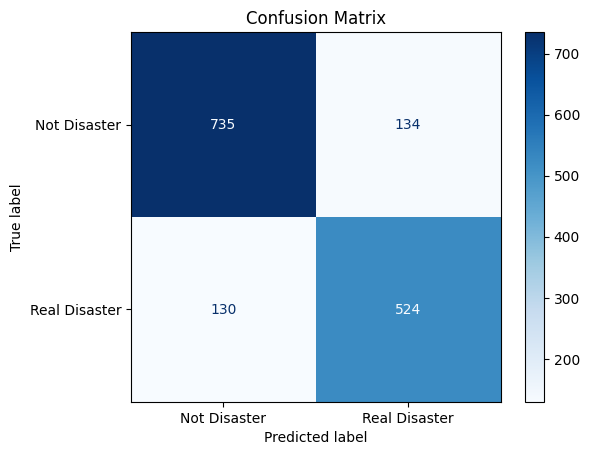

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

y_true = []
y_pred = []

model.eval()
print("🔄 กำลังสร้าง Confusion Matrix...")

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch.pop("labels")
        outputs = model(**batch)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(id2label.values()))

plt.figure(figsize=(10,10))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.show()